# Step 8. 포트폴리오 요약 — 전체 한눈에 보기 + 1장 슬라이드 생성

이 노트북은 앞선 전 과정을 한 페이지로 압축한다.
1. 전체 모델 성능을 한 표로 집계
2. SHAP 핵심 센서 재집계
3. **포트폴리오용 1장 슬라이드(PNG)** 자동 생성 → `outputs/portfolio_slide.png`

> 핵심 메시지: *"단순히 모델 정확도를 높이는 것이 아니라, 어떤 공정 변수가 수율 불량에 영향을 주는지 해석하는 데 집중했습니다."*

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import joblib
import shap
from matplotlib.patches import FancyBboxPatch
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

sns.set_style('whitegrid')
mpl.rcParams['font.family'] = 'Arial Unicode MS'
mpl.rcParams['axes.unicode_minus'] = False

FIG_DIR = os.path.join('..', 'outputs', 'figures')
PROC_DIR = os.path.join('..', 'data', 'processed')
MODEL_DIR = os.path.join('..', 'outputs', 'models')
OUT_DIR = os.path.join('..', 'outputs')
print('준비 완료')

준비 완료


In [2]:
# 데이터 + 모델 로드
data = np.load(os.path.join(PROC_DIR, 'secom_processed.npz'), allow_pickle=True)
X_test, y_test = data['X_test'], data['y_test']
feature_names = list(data['feature_names'])

def eval_saved(name, fname):
    b = joblib.load(os.path.join(MODEL_DIR, fname))
    m, thr = b['model'], b['threshold']
    proba = m.predict_proba(X_test)[:, 1]
    pred = (proba >= thr).astype(int)
    return {'model': name,
            'Recall': round(recall_score(y_test, pred), 3),
            'Precision': round(precision_score(y_test, pred, zero_division=0), 3),
            'F1': round(f1_score(y_test, pred, zero_division=0), 3),
            'ROC-AUC': round(roc_auc_score(y_test, proba), 3)}

summary = pd.DataFrame([
    eval_saved('RF(기본)', 'random_forest.joblib'),
    eval_saved('RF(튜닝)', 'random_forest_tuned.joblib'),
    eval_saved('XGB(튜닝)', 'xgboost_tuned.joblib'),
    eval_saved('LGBM(튜닝)', 'lightgbm_tuned.joblib'),
]).set_index('model')
print('전체 모델 성능 요약 (test)')
print(summary.to_string())

전체 모델 성능 요약 (test)
          Recall  Precision     F1  ROC-AUC
model                                      
RF(기본)     0.333      0.292  0.311    0.805
RF(튜닝)     0.571      0.203  0.300    0.768
XGB(튜닝)    0.286      0.375  0.324    0.734
LGBM(튜닝)   0.524      0.147  0.229    0.699


/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [3]:
# SHAP 핵심 센서 재집계 (기본 RF — TreeExplainer가 바로 적용되는 단일 분류기)
rf = joblib.load(os.path.join(MODEL_DIR, 'random_forest.joblib'))['model']
X_test_df = pd.DataFrame(X_test, columns=feature_names)
sv = shap.TreeExplainer(rf).shap_values(X_test_df)
shap_vals = sv[1] if isinstance(sv, list) else (sv[:, :, 1] if sv.ndim == 3 else sv)
mean_abs = np.abs(shap_vals).mean(axis=0)
top = (pd.Series(mean_abs, index=feature_names)
       .sort_values(ascending=False).head(8))
print('SHAP 상위 8 센서:')
print(top.round(4))

SHAP 상위 8 센서:
sensor_519    0.0176
sensor_095    0.0168
sensor_511    0.0157
sensor_247    0.0142
sensor_059    0.0142
sensor_345    0.0131
sensor_033    0.0115
sensor_385    0.0105
dtype: float64


## 포트폴리오 1장 슬라이드 생성

문제·데이터, 모델 비교, 핵심 센서, 파이프라인·인사이트를 16:9 한 페이지로 구성한다.

슬라이드 저장: outputs/portfolio_slide.png


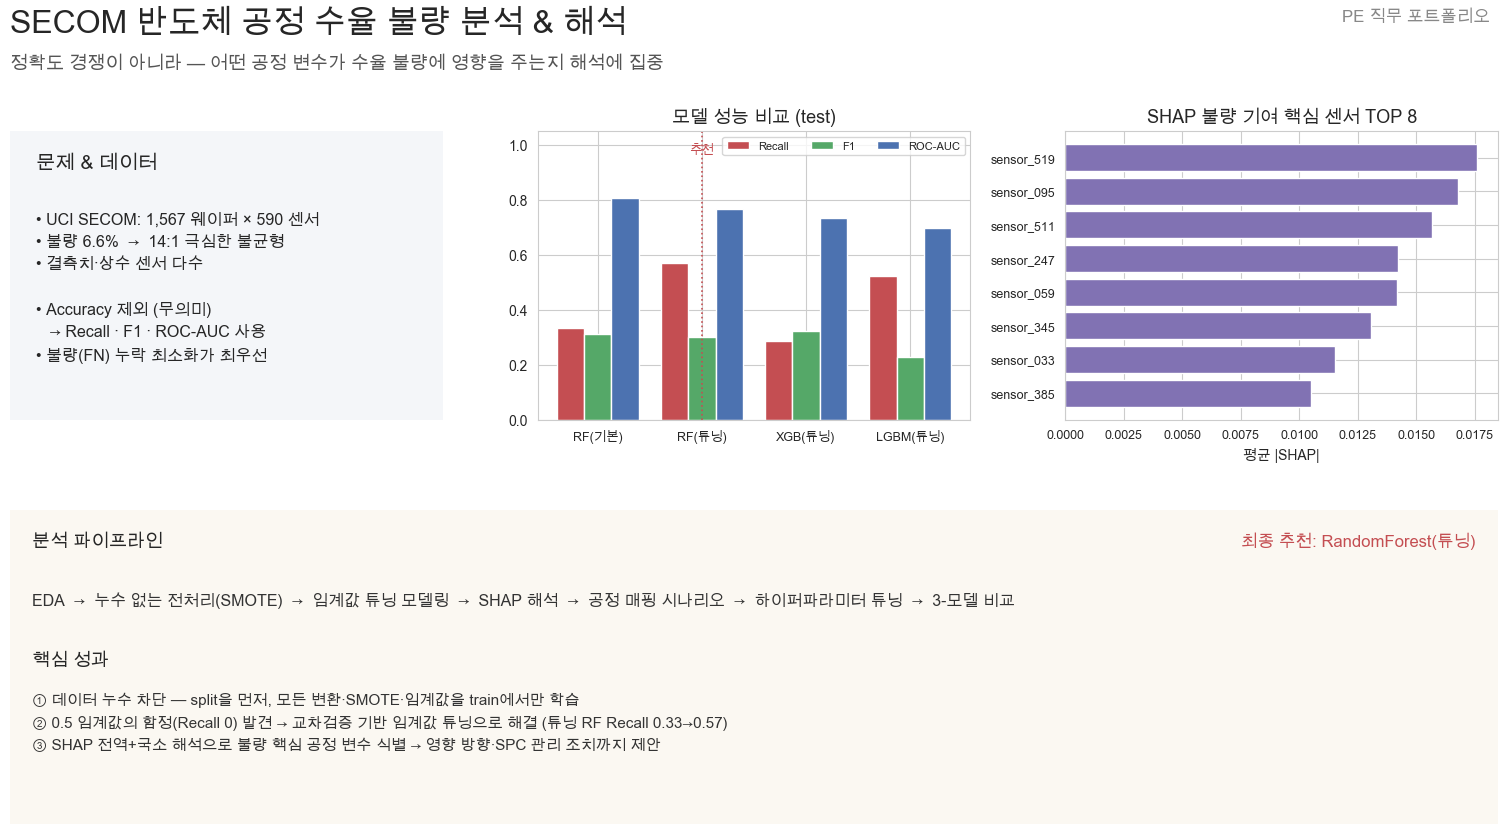

In [4]:
fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor('white')
gs = fig.add_gridspec(2, 3, height_ratios=[0.92, 1.0],
                      left=0.04, right=0.97, top=0.82, bottom=0.05, hspace=0.30, wspace=0.22)

# ── 헤더 ──
fig.text(0.04, 0.955, 'SECOM 반도체 공정 수율 불량 분석 & 해석',
         fontsize=23, fontweight='bold', va='top')
fig.text(0.04, 0.905, '정확도 경쟁이 아니라 — 어떤 공정 변수가 수율 불량에 영향을 주는지 해석에 집중',
         fontsize=13, color='#555', va='top')
fig.text(0.965, 0.955, 'PE 직무 포트폴리오', fontsize=12, color='#888', va='top', ha='right')

# ── (a) 문제 & 데이터 ──
ax_a = fig.add_subplot(gs[0, 0]); ax_a.axis('off')
ax_a.add_patch(FancyBboxPatch((0, 0), 1, 1, boxstyle='round,pad=0.02',
               fc='#F4F6F9', ec='#D0D7E2', transform=ax_a.transAxes))
ax_a.text(0.06, 0.92, '문제 & 데이터', fontsize=14, fontweight='bold', va='top')
ax_a.text(0.06, 0.72,
          '• UCI SECOM: 1,567 웨이퍼 × 590 센서\n'
          '• 불량 6.6%  →  14:1 극심한 불균형\n'
          '• 결측치·상수 센서 다수\n\n'
          '• Accuracy 제외 (무의미)\n'
          '   → Recall · F1 · ROC-AUC 사용\n'
          '• 불량(FN) 누락 최소화가 최우선',
          fontsize=11.5, va='top', linespacing=1.6)

# ── (b) 모델 성능 비교 ──
ax_b = fig.add_subplot(gs[0, 1])
metrics = ['Recall', 'F1', 'ROC-AUC']
colors = ['#C44E52', '#55A868', '#4C72B0']
x = np.arange(len(summary)); w = 0.26
for i, (m, c) in enumerate(zip(metrics, colors)):
    ax_b.bar(x + (i-1)*w, summary[m], w, label=m, color=c)
ax_b.set_xticks(x); ax_b.set_xticklabels(summary.index, fontsize=9)
ax_b.set_ylim(0, 1.05); ax_b.set_title('모델 성능 비교 (test)', fontsize=13, fontweight='bold')
ax_b.legend(fontsize=8, loc='upper right', ncol=3)
ax_b.axvline(1, color='#C44E52', ls=':', lw=1.2)
ax_b.text(1, 0.97, '추천', color='#C44E52', ha='center', fontsize=9, fontweight='bold')

# ── (c) SHAP 핵심 센서 ──
ax_c = fig.add_subplot(gs[0, 2])
ax_c.barh(top.index[::-1], top.values[::-1], color='#8172B3')
ax_c.set_title('SHAP 불량 기여 핵심 센서 TOP 8', fontsize=13, fontweight='bold')
ax_c.set_xlabel('평균 |SHAP|', fontsize=10)
ax_c.tick_params(labelsize=9)

# ── (d) 파이프라인 & 핵심 성과 ──
ax_d = fig.add_subplot(gs[1, :]); ax_d.axis('off')
ax_d.add_patch(FancyBboxPatch((0, 0), 1, 1, boxstyle='round,pad=0.01',
               fc='#FBF8F2', ec='#E5D9C3', transform=ax_d.transAxes))
ax_d.text(0.015, 0.93, '분석 파이프라인', fontsize=13, fontweight='bold', va='top')
ax_d.text(0.015, 0.74,
          'EDA  →  누수 없는 전처리(SMOTE)  →  임계값 튜닝 모델링  →  SHAP 해석  →  공정 매핑 시나리오  →  하이퍼파라미터 튜닝  →  3-모델 비교',
          fontsize=11.5, va='top', color='#333')
ax_d.text(0.015, 0.55, '핵심 성과', fontsize=13, fontweight='bold', va='top')
ax_d.text(0.015, 0.42,
          '① 데이터 누수 차단 — split을 먼저, 모든 변환·SMOTE·임계값을 train에서만 학습\n'
          '② 0.5 임계값의 함정(Recall 0) 발견 → 교차검증 기반 임계값 튜닝으로 해결 (튜닝 RF Recall 0.33→0.57)\n'
          '③ SHAP 전역+국소 해석으로 불량 핵심 공정 변수 식별 → 영향 방향·SPC 관리 조치까지 제안',
          fontsize=11, va='top', linespacing=1.7, color='#333')
ax_d.text(0.985, 0.93, '최종 추천: RandomForest(튜닝)', fontsize=12, fontweight='bold',
          va='top', ha='right', color='#C44E52')

fig.savefig(os.path.join(OUT_DIR, 'portfolio_slide.png'), dpi=120,
            bbox_inches='tight', facecolor='white')
print('슬라이드 저장: outputs/portfolio_slide.png')
plt.show()

## 프로젝트 내러티브 (발표용 대본)

**1. 문제 정의** — SECOM 반도체 공정 데이터는 590개 센서로 웨이퍼의 정상/불량을 가린다. 불량이 6.6%뿐인 극심한 불균형이라 정확도는 무의미하고, **불량을 놓치지 않는 Recall**이 핵심이다.

**2. 전처리(누수 차단)** — train/test를 먼저 나누고, 결측 제거 기준·median·분산 판정·SMOTE를 **모두 train에서만** 학습했다. 검증 성능이 부풀려지는 흔한 실수를 의식적으로 막았다.

**3. 모델링(임계값 튜닝)** — SMOTE로 학습해도 기본 임계값 0.5에선 Recall이 0이었다. SMOTE를 교차검증 파이프라인에 넣어 **누수 없이 임계값을 선택**, Recall을 회복시켰다.

**4. 해석(SHAP)** — 모델을 블랙박스로 두지 않고, 590개 센서 중 불량을 좌우하는 핵심 변수를 추렸다. 전역(중요도)+국소(개별 웨이퍼)를 모두 설명했다.

**5. 조치 연결** — SHAP 영향 방향을 데이터로 계산하고 가상 공정 매핑을 붙여, **"어떤 공정을 상·하한으로 관리할지"** 라는 PE 조치 제안으로 연결했다.

**6. 최적화·비교** — RF·XGB·LightGBM을 동일 절차로 튜닝·비교해 근거 있게 최종 모델(RandomForest 튜닝)을 선택했다.

> **마무리**: SECOM은 신호가 약한 어려운 데이터라 절대 성능은 높지 않다. 그러나 이 프로젝트의 가치는 점수가 아니라 **누수 없는 설계 · 임계값 의사결정 · 해석 가능성**이라는 방법론에 있으며, 이는 수율 개선을 다루는 Product Engineering 업무와 직접 맞닿아 있다.